# YOLO-seg 기반 2D 포즈 추정

카메라에서 정지 프레임 한 장을 가져와 객체의 **중심 `(u, v)`**과 **장축 각도 `θ`**를 계산한다.

처리 흐름: `정지 프레임 → YOLO-seg 마스크 → 마스크 정리 → 중심 및 PCA 각도 → 결과 표시`

> 각도는 객체 축의 방향이므로 `θ`와 `θ + 180°`를 같은 자세로 보고 `[-90°, 90°)` 범위로 표시한다.

## 1. 모델과 실행 환경 준비

`lerobot` 커널을 사용한다. 학습된 세그멘테이션 가중치 `weights/best-seg.pt`를 GPU에 로드한다.

In [29]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for start in (here, *here.parents):
        if (start / "vision").is_dir() and (start / "yolo").is_dir():
            return start
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했습니다. Project/ 또는 yolo/ 에서 노트북을 여세요."
    )

PROJECT = _project_root()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from vision.camera import grab_bgr, open_camera

WEIGHTS = PROJECT / "yolo" / "weights" / "best-seg.pt"
if not WEIGHTS.is_file():
    raise FileNotFoundError(f"세그 가중치가 없습니다: {WEIGHTS}")

device = 0 if torch.cuda.is_available() else "cpu"
model = YOLO(str(WEIGHTS))
print(f"weights={WEIGHTS.name}, device={device}")

weights=best-seg.pt, device=0


## 2. 정지 프레임 촬영

카메라를 사용하는 다른 프로그램을 먼저 종료한다. 아래 셀은 초기 프레임을 몇 장 버린 뒤 분석할 프레임 한 장을 저장한다.

frame shape=(480, 640, 3)


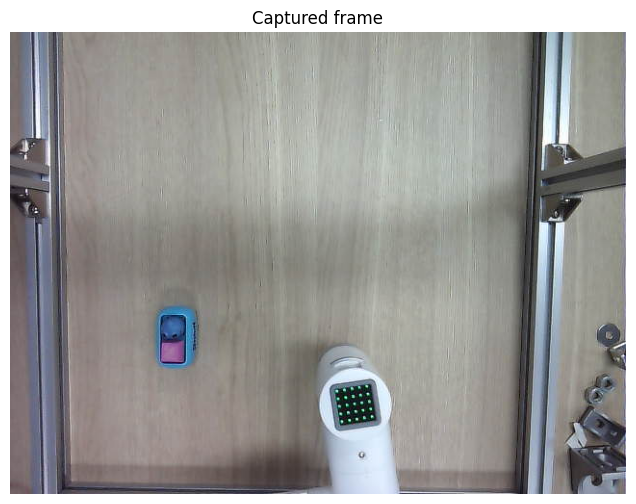

In [34]:
cap = open_camera()
try:
    frame = None
    for _ in range(10):
        # 캘리브레이션/검증에 사용한 Orbbec SDK 영상 방향과 동일하게 유지한다.
        # vision.camera의 기본값은 180° 회전이므로 이 노트북에서는 명시적으로 끈다.
        frame = grab_bgr(cap, rotate_180=False)
finally:
    cap.release()

if frame is None:
    raise RuntimeError("카메라 프레임을 가져오지 못했습니다.")

print(f"frame shape={frame.shape}")
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Captured frame")
plt.show()

## 3. 마스크에서 중심과 각도 계산

가장 신뢰도가 높은 객체 하나를 선택한다. 마스크의 작은 구멍을 정리하고 가장 큰 연결 성분에서 중심과 PCA 장축을 계산한다.

- `(u, v)`: 마스크의 무게중심
- `θ`: 화면에서 오른쪽 방향을 0°로 둔 장축 각도
- `axis confidence`: 1에 가까울수록 장축이 뚜렷하고, 0에 가까우면 방향 판단이 어렵다.

center=(172.2, 315.3) px
theta=86.1 deg (mod 180°)
detect confidence=0.914
axis confidence=0.563


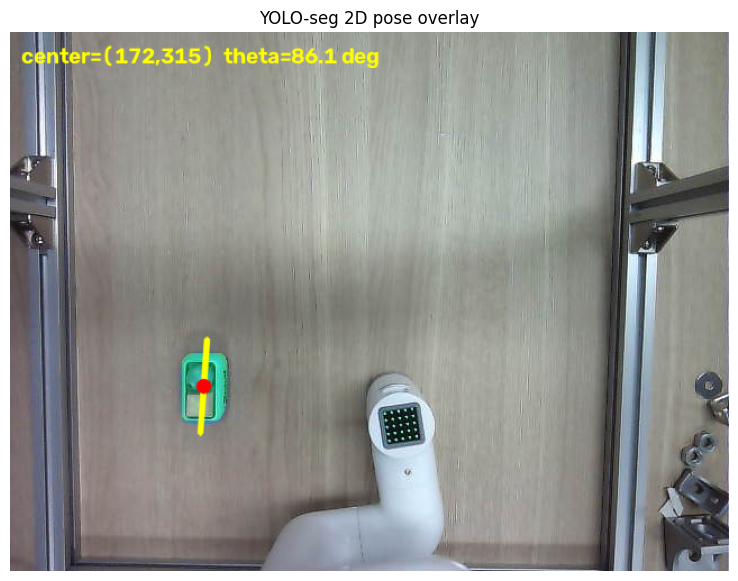

In [31]:
def clean_mask(mask: np.ndarray) -> np.ndarray:
    """작은 구멍을 닫고 가장 큰 객체 영역만 남긴다."""
    binary = (mask > 0).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    count, labels, stats, _ = cv2.connectedComponentsWithStats(binary, 8)
    if count <= 1:
        raise ValueError("유효한 마스크 영역이 없습니다.")
    largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    return labels == largest


def pose_from_mask(mask: np.ndarray) -> dict:
    """마스크 중심과 180° 주기의 PCA 장축 각도를 계산한다."""
    ys, xs = np.nonzero(mask)
    if len(xs) < 20:
        raise ValueError("포즈를 계산할 마스크 픽셀이 부족합니다.")

    points = np.column_stack((xs, ys)).astype(np.float64)
    center = points.mean(axis=0)
    centered = points - center
    covariance = np.cov(centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    axis = eigenvectors[:, order[0]]

    # 영상의 y축은 아래 방향이므로 부호를 뒤집어 수학적 반시계 각도로 변환한다.
    theta = np.degrees(np.arctan2(-axis[1], axis[0]))
    theta = (theta + 90.0) % 180.0 - 90.0
    axis_confidence = 1.0 - float(eigenvalues[1] / max(eigenvalues[0], 1e-9))

    return {
        "center": center,
        "axis": axis,
        "theta_deg": theta,
        "axis_confidence": axis_confidence,
        "eigenvalues": eigenvalues,
    }


results = model.predict(frame, conf=0.4, imgsz=640, device=device, verbose=False)
result = results[0]
if result.boxes is None or len(result.boxes) == 0 or result.masks is None:
    raise RuntimeError("세그멘테이션된 객체를 찾지 못했습니다.")

confidences = result.boxes.conf.detach().cpu().numpy()
index = int(np.argmax(confidences))
raw_mask = result.masks.data[index].detach().cpu().numpy().astype(np.float32)
h, w = frame.shape[:2]
raw_mask = cv2.resize(raw_mask, (w, h), interpolation=cv2.INTER_LINEAR) > 0.5
mask = clean_mask(raw_mask)
pose = pose_from_mask(mask)

u, v = pose["center"]
print(f"center=({u:.1f}, {v:.1f}) px")
print(f"theta={pose['theta_deg']:.1f} deg (mod 180°)")
print(f"detect confidence={confidences[index]:.3f}")
print(f"axis confidence={pose['axis_confidence']:.3f}")

# 계산 결과를 원본 이미지 위에 바로 겹쳐 표시한다.
overlay = frame.copy()
green = np.zeros_like(overlay)
green[mask] = (0, 255, 0)
overlay = cv2.addWeighted(overlay, 1.0, green, 0.30, 0.0)

center = pose["center"]
axis = pose["axis"]
length = 2.5 * np.sqrt(pose["eigenvalues"][0])
p1 = np.rint(center - axis * length).astype(int)
p2 = np.rint(center + axis * length).astype(int)
c = tuple(np.rint(center).astype(int))

cv2.line(overlay, tuple(p1), tuple(p2), (0, 255, 255), 3, cv2.LINE_AA)
cv2.circle(overlay, c, 6, (0, 0, 255), -1, cv2.LINE_AA)
cv2.putText(
    overlay,
    f"center=({c[0]},{c[1]})  theta={pose['theta_deg']:.1f} deg",
    (10, 28),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.65,
    (0, 255, 255),
    2,
    cv2.LINE_AA,
)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO-seg 2D pose overlay")
plt.show()

### 4. 로봇 타깃 `[x, y, z, rx, ry, rz]` 생성

Depth를 사용하지 않고, 하드코딩한 책상 Z와 물체 높이로 물체 윗면 평면을 만든다. 카메라 광선과 이 평면의 교점으로 중심 및 장축을 로봇 베이스 좌표계에 투영한다.

- `TABLE_Z`: 로봇 베이스 원점에서 본 책상 표면 Z
- `OBJECT_HEIGHT`: 책상에서 물체 윗면까지의 높이
- `POSE_PLANE_Z`: `(x, y)` 계산에 사용하는 물체 윗면 Z
- `GRASP_OFFSET_Z`: 물체 윗면에서 그리퍼 TCP까지의 간격
- 이 셀은 좌표만 계산하며 로봇을 움직이지 않는다.

In [32]:
import json

CALIB_DIR = PROJECT / "vision" / "calib_data"
INTRINSICS_JSON = CALIB_DIR / "intrinsics.json"
HANDEYE_JSON = CALIB_DIR / "eye_to_hand.json"

# 아래 Z 값은 Depth 측정값이 아니라 로봇 베이스 좌표계 기준의 하드코딩 상수다.
TABLE_Z = -10.0          # 로봇 베이스 원점에서 본 책상 표면 Z
OBJECT_HEIGHT = 30.0     # 책상 표면에서 물체 윗면까지 높이
GRASP_OFFSET_Z = 20.0     # 물체 윗면에서 그리퍼 TCP를 띄울 거리

POSE_PLANE_Z = TABLE_Z + OBJECT_HEIGHT
GRASP_Z = POSE_PLANE_Z + GRASP_OFFSET_Z
GRIP_YAW_OFFSET_DEG = 0.0  # 그리퍼 손가락 방향에 따라 0° 또는 90° 등으로 조정

intrinsics = json.loads(INTRINSICS_JSON.read_text(encoding="utf-8"))
handeye = json.loads(HANDEYE_JSON.read_text(encoding="utf-8"))
K = np.asarray(intrinsics["camera_matrix"], dtype=np.float64)
dist = np.asarray(intrinsics["dist_coeffs"], dtype=np.float64)
T_base_cam = np.asarray(handeye["T_base_cam"], dtype=np.float64)

expected_size = tuple(int(value) for value in intrinsics["image_size"])
actual_size = (int(frame.shape[1]), int(frame.shape[0]))
if actual_size != expected_size:
    raise RuntimeError(
        f"캘리브레이션 영상 크기 {expected_size}와 현재 프레임 {actual_size}가 다릅니다."
    )
if T_base_cam.shape != (4, 4):
    raise RuntimeError(f"T_base_cam 형식 오류: {T_base_cam.shape}")


def pixels_to_base_plane(points_uv: np.ndarray, plane_z_mm: float) -> np.ndarray:
    """왜곡 보정된 카메라 광선과 베이스 좌표계의 고정 Z 평면을 교차한다."""
    points_uv = np.asarray(points_uv, dtype=np.float64).reshape(-1, 1, 2)
    normalized = cv2.undistortPoints(points_uv, K, dist).reshape(-1, 2)
    rays_cam = np.column_stack([normalized, np.ones(len(normalized))])

    rotation = T_base_cam[:3, :3]
    camera_origin_base = T_base_cam[:3, 3]
    rays_base = (rotation @ rays_cam.T).T
    denominator = rays_base[:, 2]
    if np.any(np.abs(denominator) < 1e-9):
        raise RuntimeError("카메라 광선이 목표 평면과 평행합니다.")

    scales = (float(plane_z_mm) - camera_origin_base[2]) / denominator
    if np.any(scales <= 0):
        raise RuntimeError("목표 평면이 카메라 앞쪽에 있지 않습니다. GRASP_Z를 확인하세요.")
    return camera_origin_base + scales[:, None] * rays_base


center_uv = np.asarray(pose["center"], dtype=np.float64)
axis_uv = np.asarray(pose["axis"], dtype=np.float64)
axis_span_px = 50.0
image_points = np.vstack(
    [center_uv, center_uv - axis_uv * axis_span_px, center_uv + axis_uv * axis_span_px]
)
# (x, y)는 물체 윗면 평면에서 계산하고, 실제 그립 Z는 별도로 사용한다.
base_points = pixels_to_base_plane(image_points, POSE_PLANE_Z)

x, y = base_points[0, :2]
axis_base = base_points[2, :2] - base_points[1, :2]
yaw = np.degrees(np.arctan2(axis_base[1], axis_base[0])) + GRIP_YAW_OFFSET_DEG
# PCA 장축은 180° 주기이므로 동등한 각도 중 [-90, 90) 표현을 사용한다.
yaw = (yaw + 90.0) % 180.0 - 90.0

target = [float(x), float(y), float(GRASP_Z), 180.0, 0.0, float(yaw)]
#if abs(x) > 281.45 or abs(y) > 281.45:
 #   raise RuntimeError(f"계산된 XY가 로봇 작업 범위를 벗어났습니다: {target[:2]}")

print("Z 상수", {
    "TABLE_Z": TABLE_Z,
    "OBJECT_HEIGHT": OBJECT_HEIGHT,
    "POSE_PLANE_Z": POSE_PLANE_Z,
    "GRASP_OFFSET_Z": GRASP_OFFSET_Z,
    "GRASP_Z": GRASP_Z,
})
print("image center (u, v)", np.round(center_uv, 1).tolist())
print("base x, y, yaw", [round(float(x), 1), round(float(y), 1), round(float(yaw), 1)])
print("target", [round(value, 1) for value in target])
if pose["axis_confidence"] < 0.3:
    print("경고: axis confidence가 낮아 yaw가 불안정할 수 있습니다.")

Z 상수 {'TABLE_Z': -10.0, 'OBJECT_HEIGHT': 30.0, 'POSE_PLANE_Z': 20.0, 'GRASP_OFFSET_Z': 20.0, 'GRASP_Z': 40.0}
image center (u, v) [172.2, 315.3]
base x, y, yaw [313.8, -132.0, -4.4]
target [313.8, -132.0, 40.0, 180.0, 0.0, -4.4]
